## Data import

In [8]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


In [9]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

In [2]:
for name, dataset in datasets.items():
    print(dataset.summary())
    display(dataset.sensors.head())

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.134422,0.128272,0.102251,0.104552,0.099477,0.026017,0.395401,0.041172,1.988174,0.345307,...,987.024170,997.685425,20.788589,19.79677,19.106760,35.205521,27.12253,88.334503,43.250599,2.2100
1,0.134377,0.128434,0.102302,0.104471,0.099487,0.026034,0.470502,0.041136,1.989220,0.128820,...,987.656128,997.685486,20.789459,19.79862,18.965611,35.207569,27.11714,88.385307,43.258072,2.2900
2,0.134632,0.128661,0.102409,0.104656,0.099497,0.026203,0.429733,0.041123,1.992013,0.014496,...,988.288086,997.685486,20.790331,19.80048,18.918560,35.209610,27.11174,88.436111,43.265541,2.1000
3,0.134634,0.128690,0.102516,0.104800,0.099507,0.026164,0.316007,0.041084,1.994807,0.458081,...,988.919983,997.685486,20.791210,19.80234,18.918560,35.211651,27.10635,88.486923,43.273010,1.9975
4,0.134763,0.128653,0.102623,0.104902,0.099517,0.026040,0.292404,0.041065,1.997600,0.412542,...,989.552002,997.685608,20.792080,19.80419,18.918560,35.213699,27.10095,88.537727,43.280479,2.1775


TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.148614,0.144112,0.099908,0.102331,0.099692,0.044019,0.657899,0.021139,3.493562,-0.119259,...,278.099609,998.15802,21.240061,21.056549,20.549940,34.029011,20.176050,47.243179,56.314251,2.4075
1,0.148712,0.144223,0.099980,0.102346,0.099749,0.044139,0.664337,0.021129,3.493410,-0.204256,...,274.954712,998.15802,21.240170,21.055470,20.549940,34.016430,20.188910,47.229820,56.316959,2.4150
2,0.148811,0.144334,0.100075,0.102346,0.099805,0.044162,0.675781,0.021120,3.493258,-0.246815,...,278.543915,998.15802,21.240280,21.054399,20.549940,34.003399,20.201780,47.216461,56.319679,2.3925
3,0.148909,0.144444,0.100153,0.102410,0.099861,0.044153,0.700099,0.021112,3.493105,-0.122358,...,280.331696,998.15802,21.240391,21.053320,20.597019,33.990379,20.214649,47.203110,56.322392,2.4950
4,0.149008,0.144440,0.100224,0.102479,0.099917,0.044143,0.709398,0.021104,3.492953,-0.041533,...,285.598602,998.15802,21.240490,21.052250,20.612711,33.977360,20.227510,47.189751,56.325100,2.5000


In [10]:
X_train_list = []
y_train_list = []

for name, dataset in datasets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()

    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    healthy = df.iloc[:fault_start].copy()
    faulty = df.iloc[fault_start:fault_end + 1].copy()

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, axis=0, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_training_dataset = TimeSeriesDataset(
    name="FDA_training_data",
    sensors=X_fda,
    metadata={"description": "Pooled healthy/fault labelled data"},
)

display(pd.Series(y_fda).value_counts().rename(index={0: "healthy", 1: "fault"}))

fault      9738
healthy    2914
Name: count, dtype: int64

In [11]:
preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_scaled_dataset = preprocessor.fit_transform(fda_training_dataset)
X_np = X_scaled_dataset.to_numpy()

classes = np.unique(y_fda)
n, m = X_np.shape
p = len(classes)

print("X shape:", X_np.shape)
print("Classes:", classes)

X shape: (12652, 23)
Classes: [0 1]


In [12]:
xbar = X_np.mean(axis=0).reshape(-1, 1)

Sw = np.zeros((m, m))
Sb = np.zeros((m, m))

for c in classes:
    Xc = X_np[y_fda == c]
    mu_c = Xc.mean(axis=0).reshape(-1, 1)

    Xc_centered = Xc - mu_c.ravel()
    Sw += Xc_centered.T @ Xc_centered

    d = mu_c - xbar
    Sb += Xc.shape[0] * (d @ d.T)

eps = 1e-6
Sw_reg = Sw + eps * np.eye(m)

eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Sw_reg) @ Sb)
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

Wp = eigvecs[:, :p - 1]

print("Top FDA eigenvalues:", eigvals[:p - 1])

Top FDA eigenvalues: [1.26885357]


In [13]:
Z_train = X_np @ Wp

muZ = {}
SigmaZ = {}

for c in classes:
    Zc = Z_train[y_fda == c]
    muZ[c] = Zc.mean(axis=0).reshape(-1, 1)

    cov = np.cov(Zc.T)
    cov = np.atleast_2d(cov)
    SigmaZ[c] = cov + 1e-6 * np.eye(cov.shape[0])

fda_train_df = pd.DataFrame({
    "z1": Z_train[:, 0],
    "class": y_fda,
})

display(fda_train_df.groupby("class")["z1"].describe())

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,2914.0,0.285577,0.203486,-0.046409,0.108240,0.223207,0.457675,0.792908
1,9738.0,-0.085456,0.112267,-0.532126,-0.168088,-0.090275,-0.014103,0.532078


In [14]:
def fda_predict(dataset):
    X_test_scaled = preprocessor.transform(dataset).to_numpy()
    Z_test = X_test_scaled @ Wp

    classes_sorted = sorted(muZ.keys())
    T2_to_classes = np.zeros((len(Z_test), len(classes_sorted)))

    for i in range(len(Z_test)):
        zi = Z_test[i].reshape(-1, 1)

        for j, c in enumerate(classes_sorted):
            d = zi - muZ[c]
            T2_to_classes[i, j] = (d.T @ np.linalg.pinv(SigmaZ[c]) @ d).item()

    pred_idx = np.argmin(T2_to_classes, axis=1)
    pred = np.array([classes_sorted[j] for j in pred_idx])

    return pred, Z_test, T2_to_classes

In [15]:
fda_results = {}

for name, dataset in datasets.items():
    pred, Z, T2_to_classes = fda_predict(dataset)

    y_true = make_ground_truth(
        dataset.n_samples,
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    fda_results[name] = {
        "pred": pred,
        "Z": Z,
        "T2_to_classes": T2_to_classes,
        "y_true": y_true,
    }

    print(f"\n{name}")
    print(classification_report(
        y_true,
        pred,
        target_names=["healthy", "fault"],
        zero_division=0,
    ))


Set1_1
              precision    recall  f1-score   support

     healthy       0.68      0.71      0.70      2195
       fault       0.82      0.80      0.81      3616

    accuracy                           0.76      5811
   macro avg       0.75      0.75      0.75      5811
weighted avg       0.77      0.76      0.76      5811


Set1_2
              precision    recall  f1-score   support

     healthy       0.82      0.49      0.61      1346
       fault       0.81      0.95      0.88      3121

    accuracy                           0.81      4467
   macro avg       0.82      0.72      0.75      4467
weighted avg       0.82      0.81      0.80      4467


Set1_3
              precision    recall  f1-score   support

     healthy       0.61      0.38      0.47      1320
       fault       0.77      0.89      0.83      3001

    accuracy                           0.74      4321
   macro avg       0.69      0.64      0.65      4321
weighted avg       0.72      0.74      0.72      4

In [16]:
fda_rows = []

for name, result in fda_results.items():
    detection_metrics = evaluate_alarm(
        result["pred"] == 1,
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    classifier_metrics = evaluate_classifier(
        result["y_true"],
        result["pred"],
    )

    fda_rows.append({
        "Dataset": name,
        "Model": "FDA binary classifier",
        **detection_metrics,
        **classifier_metrics,
    })

fda_summary_df = pd.DataFrame(fda_rows)
display(fda_summary_df)

,Dataset,Model,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate,accuracy,precision_fault,recall_fault,f1_fault
0,Set1_1,FDA binary classifier,1870,304,3506,10,2875,621,0.006386,0.795077,0.763896,0.820023,0.795077,0.807357
1,Set1_2,FDA binary classifier,669,12,3662,15,2977,670,0.022831,0.953861,0.814417,0.812944,0.953861,0.877783
2,Set1_3,FDA binary classifier,703,12,3499,207,2684,608,0.299566,0.894369,0.738024,0.767076,0.894369,0.825846


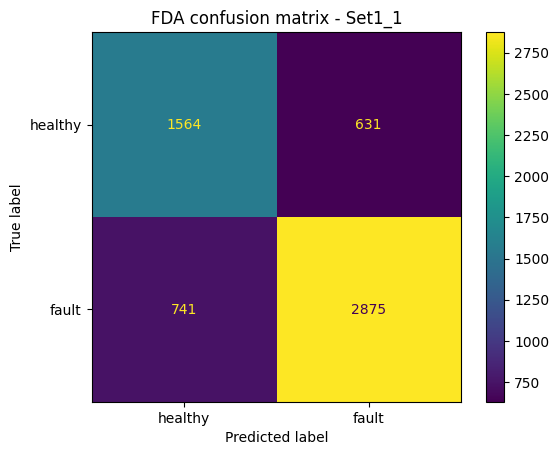

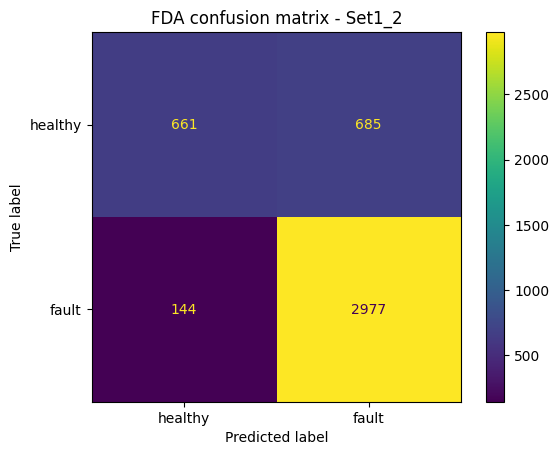

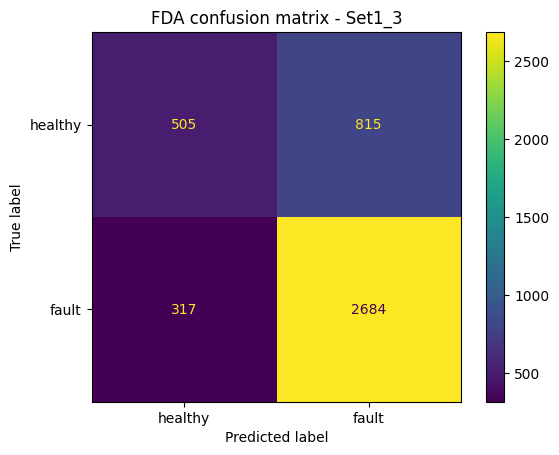

In [17]:
for name, result in fda_results.items():
    cm = confusion_matrix(result["y_true"], result["pred"])

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["healthy", "fault"],
    )

    disp.plot()
    plt.title(f"FDA confusion matrix - {name}")
    plt.show()

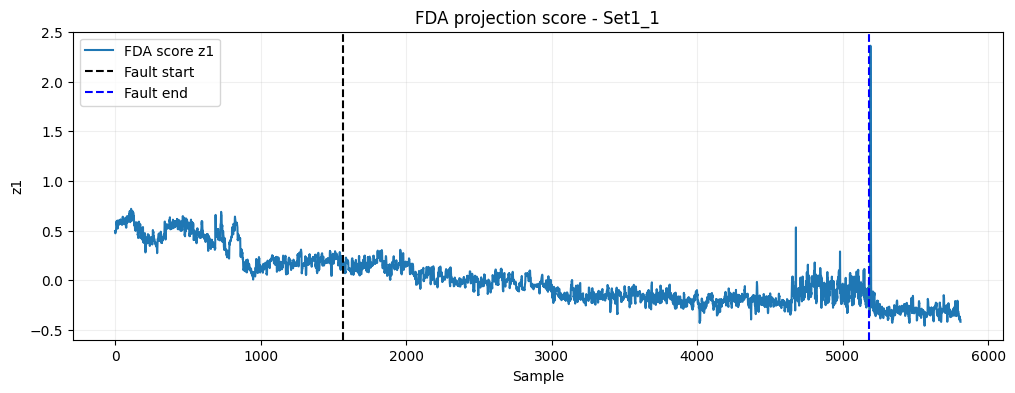

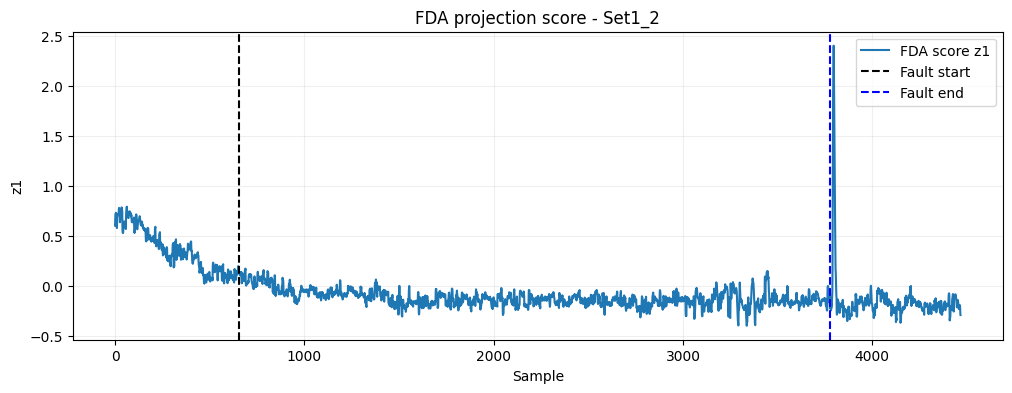

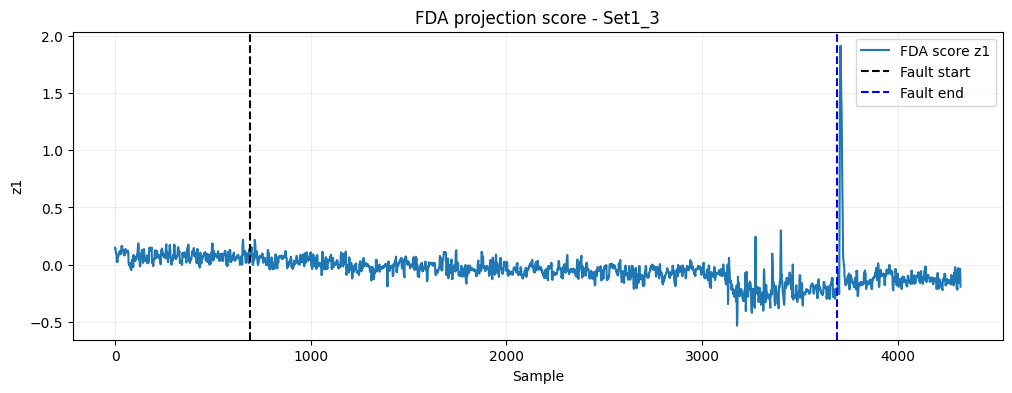

In [18]:
for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 4))
    plt.plot(result["Z"][:, 0], label="FDA score z1")
    plt.axvline(fault_start, color="black", linestyle="--", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="--", label="Fault end")
    plt.title(f"FDA projection score - {name}")
    plt.xlabel("Sample")
    plt.ylabel("z1")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

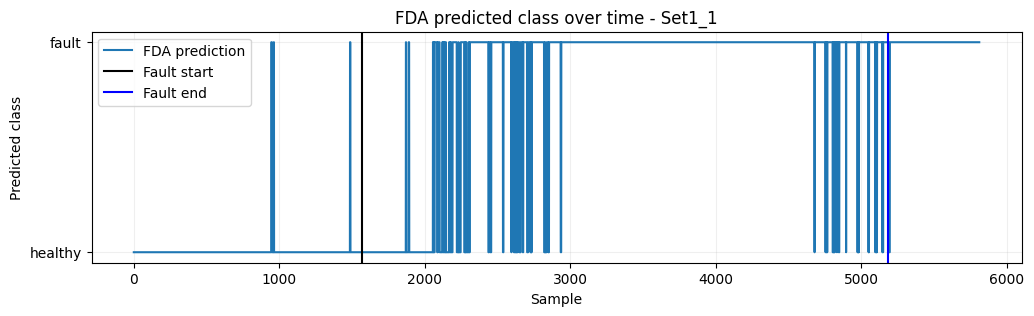

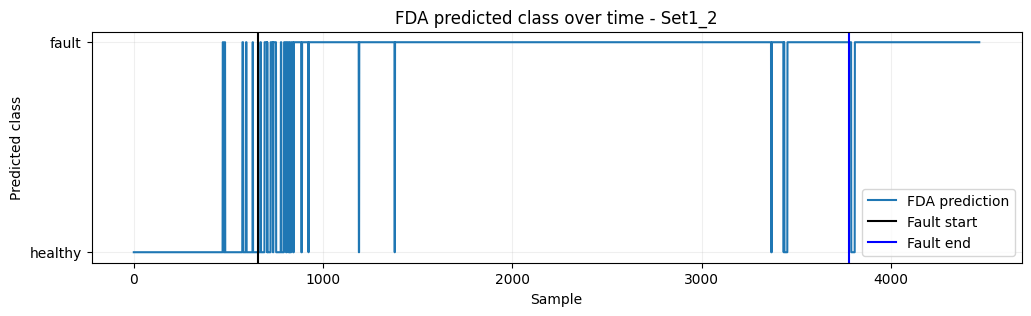

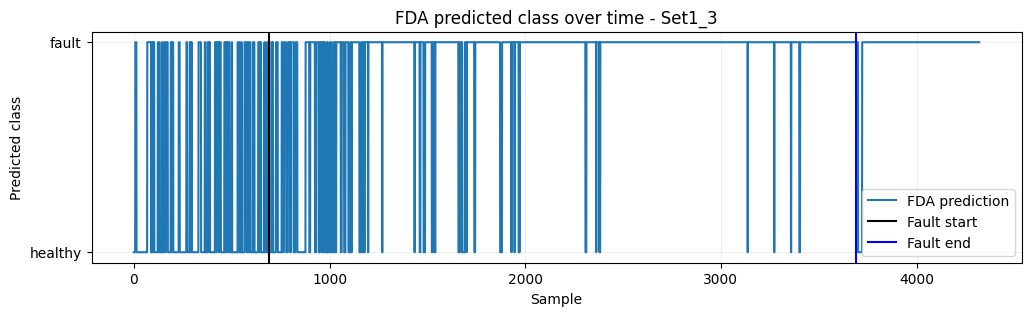

In [19]:
for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 3))
    plt.plot(result["pred"], label="FDA prediction")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA predicted class over time - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Predicted class")
    plt.yticks([0, 1], ["healthy", "fault"])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

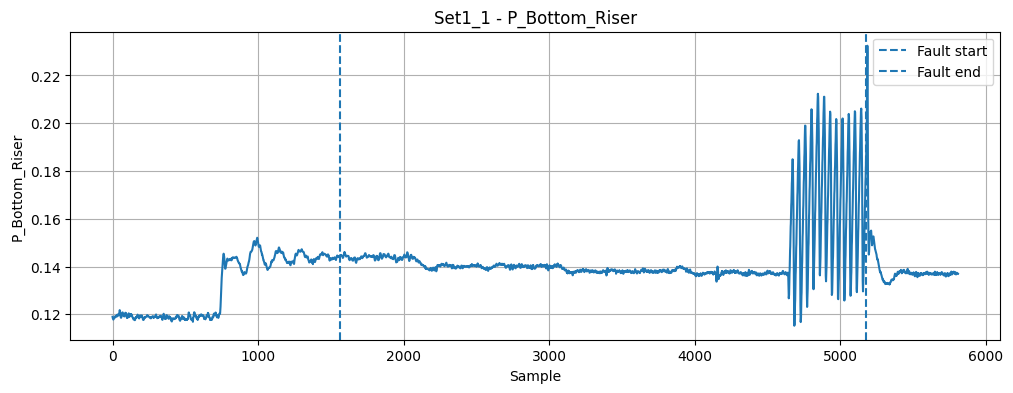

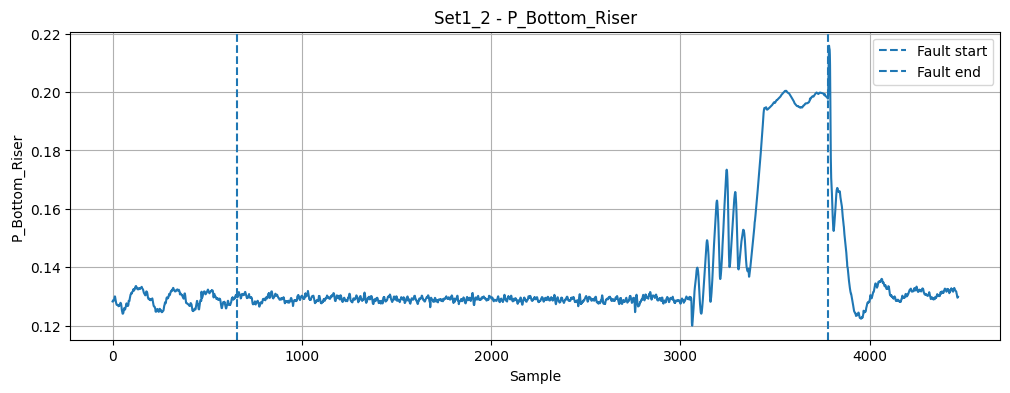

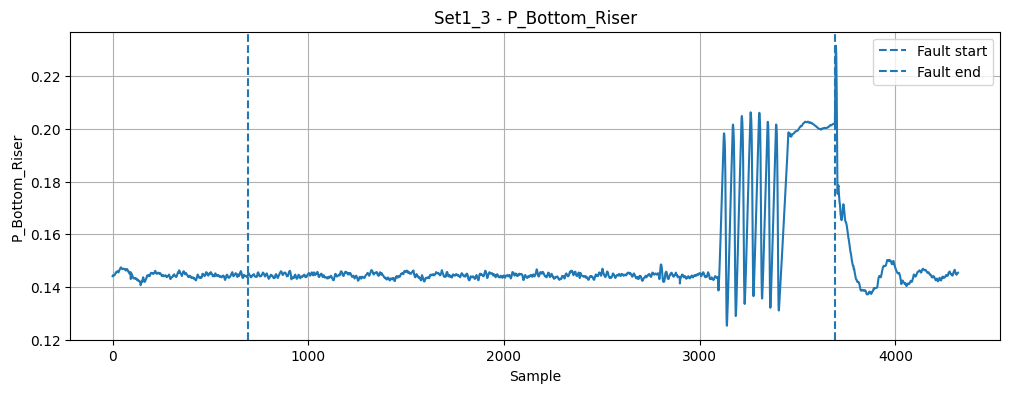

In [3]:
sensor = "P_Bottom_Riser"

for name, dataset in datasets.items():
    plt.figure(figsize=(12, 4))
    plt.plot(dataset.sensors[sensor])
    plt.axvline(fault_info[name]["start"], linestyle="--", label="Fault start")
    plt.axvline(fault_info[name]["end"], linestyle="--", label="Fault end")
    plt.title(f"{name} - {sensor}")
    plt.xlabel("Sample")
    plt.ylabel(sensor)
    plt.grid(True)
    plt.legend()
    plt.show()

## Labels

FDA er supervised, så den skal bruge labels 0 = healthy, 1 = fault

In [4]:
X_parts = []
y_parts = []

for name, dataset in datasets.items():
    X_parts.append(dataset.sensors)

    y = np.zeros(dataset.n_samples, dtype=int)
    y[fault_info[name]["start"]:fault_info[name]["end"] + 1] = 1
    y_parts.append(y)

X_all = pd.concat(X_parts, ignore_index=True)
y_all = np.concatenate(y_parts)

full_dataset = TimeSeriesDataset(
    name="FDA_training_data",
    sensors=X_all,
    metadata={"description": "Healthy and faulty labelled data"},
)

## Preprocessing

In [5]:
preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_scaled_dataset = preprocessor.fit_transform(full_dataset)
X_scaled = X_scaled_dataset.to_numpy()

## Train FDA

FDA lærer en lineær grænse mellem normal og faulty drift

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

fda = LinearDiscriminantAnalysis()
fda.fit(X_scaled, y_all)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## Test on every dataset

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

results = []

for name, dataset in datasets.items():
    X_test_scaled = preprocessor.transform(dataset).to_numpy()

    y_true = np.zeros(dataset.n_samples, dtype=int)
    y_true[fault_info[name]["start"]:fault_info[name]["end"] + 1] = 1

    y_pred = fda.predict(X_test_scaled)

    results.append({
        "Dataset": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Confusion matrix": confusion_matrix(y_true, y_pred),
    })

pd.DataFrame(results)

,Dataset,Accuracy,Confusion matrix
0,Set1_1,0.878334,"[[1507, 688], [19, 3597]]"
1,Set1_2,0.953212,"[[1140, 206], [3, 3118]]"
2,Set1_3,0.738718,"[[368, 952], [177, 2824]]"
